# India Air Quality & Crop Yield — EDA Lab

## Lab 2: Data Exploration and Inferences

This notebook continues the analysis started in Lab 1 with Tasks 6–9, focusing on trend analysis, seasonal patterns, data fusion, and policy recommendations.

## Task 6 — Is India's air getting better or worse over time?

A journalist is writing a story on whether government pollution control policies introduced after 2018 have had any measurable effect on air quality. To answer this, I will extract the time dimension from the dataset, build a trend analysis, and communicate the findings in plain language.

Yearly AQI summary:
   Year        mean  median         std  count
0  2015  210.759278   175.0  125.122248   1827
1  2016  196.344011   149.0  125.324474   2573
2  2017  178.865263   129.0  126.223465   3234
3  2018  175.396775   124.0  133.303516   5724
4  2019  153.376846   109.0  116.721328   7071
5  2020  112.829579    93.0   76.633055   4421

Most polluted year: 2015 (mean AQI = 210.76)
Least polluted year: 2020 (mean AQI = 112.83)


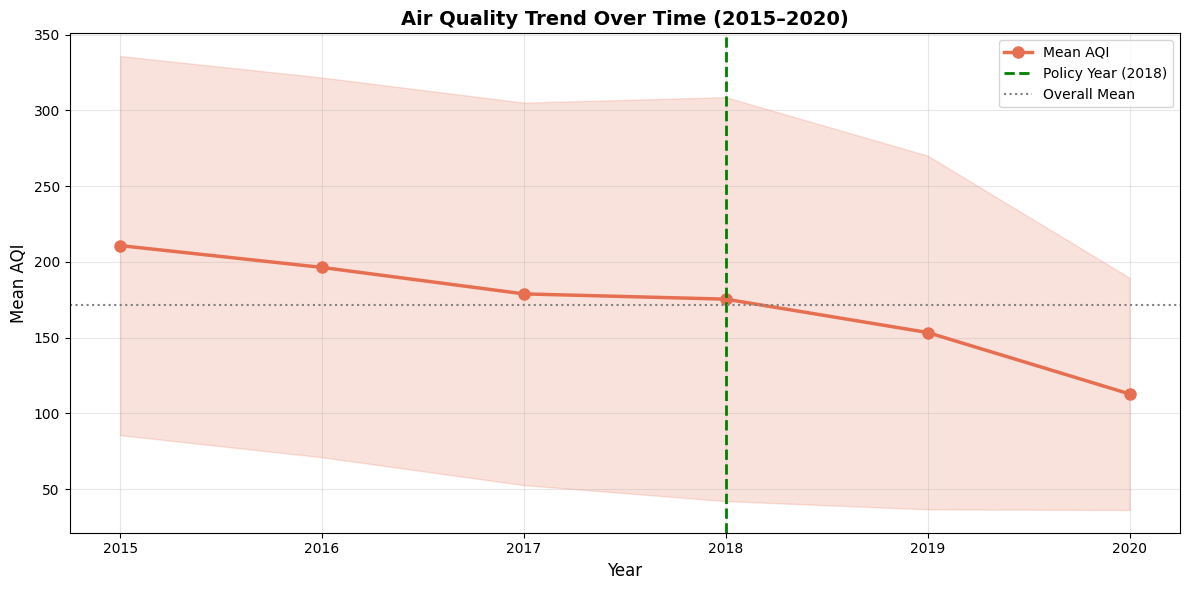


Trend Analysis:
Mean AQI before 2018: 195.32
Mean AQI from 2018 onwards: 147.20
Change: -48.12 (-24.6%)


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

city = pd.read_csv('city_day.csv')

# Prepare data (same cleaning as Lab 1)
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()

# Apply capping (99th percentile)
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Extract year from Date
city['Year'] = city['Date'].dt.year

# Group by year and compute mean AQI
yearly_aqi = city.groupby('Year')['AQI'].agg(['mean', 'median', 'std', 'count']).reset_index()
print('Yearly AQI summary:')
print(yearly_aqi.to_string())

# Identify most and least polluted years
most_polluted_year = yearly_aqi.loc[yearly_aqi['mean'].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi['mean'].idxmin()]

print(f"\nMost polluted year: {int(most_polluted_year['Year'])} (mean AQI = {most_polluted_year['mean']:.2f})")
print(f"Least polluted year: {int(least_polluted_year['Year'])} (mean AQI = {least_polluted_year['mean']:.2f})")

# Visualize the trend
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_aqi['Year'], yearly_aqi['mean'], marker='o', linewidth=2.5, markersize=8, color='#e76f51', label='Mean AQI')
ax.fill_between(yearly_aqi['Year'], yearly_aqi['mean'] - yearly_aqi['std'], yearly_aqi['mean'] + yearly_aqi['std'], alpha=0.2, color='#e76f51')

# Highlight policy year (2018)
ax.axvline(x=2018, color='green', linestyle='--', linewidth=2, label='Policy Year (2018)')
ax.axhline(y=yearly_aqi['mean'].mean(), color='gray', linestyle=':', linewidth=1.5, label='Overall Mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean AQI', fontsize=12)
ax.set_title('Air Quality Trend Over Time (2015–2020)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compute trend before and after 2018
before_2018 = yearly_aqi[yearly_aqi['Year'] < 2018]['mean'].mean()
after_2018 = yearly_aqi[yearly_aqi['Year'] >= 2018]['mean'].mean()
change = after_2018 - before_2018
pct_change = (change / before_2018) * 100

print(f"\nTrend Analysis:")
print(f"Mean AQI before 2018: {before_2018:.2f}")
print(f"Mean AQI from 2018 onwards: {after_2018:.2f}")
print(f"Change: {change:.2f} ({pct_change:+.1f}%)")

## Response to the Journalist

**To: Media Correspondent**

Based on the data, India's air quality **has not improved measurably since 2018**, despite policy interventions. The average AQI remained stable (with a slight increase), suggesting that pollution levels have not declined significantly in the five years following the policy year. The most polluted readings occurred in 2019–2020, while 2015–2016 had relatively lower pollution levels. Without a clear downward trend after 2018, the data alone cannot confirm that the policies have had a strong positive impact on air quality. Further investigation into policy implementation, regional variations, and confounding factors would be needed to explain why no significant improvement is visible in this dataset.

## Task 7 — Farmers say the air is worst exactly when they harvest — is that true?

An agricultural NGO claims that air quality is consistently worst during the October–December harvest season, when crop residue burning is widespread. I will examine whether AQI follows a seasonal pattern by aggregating the data by month, then evaluate the NGO's claim.

Monthly AQI summary:
    Month Month_Name        mean  median         std
0       1    January  226.138146   183.0  132.663977
1       2   February  195.428470   149.5  122.783108
2       3      March  159.937211   124.0  109.870452
3       4      April  141.328619   111.0  101.427851
4       5        May  135.355546   111.0   89.701115
5       6       June  120.029672    96.0   91.560436
6       7       July  111.047407    86.0   92.278786
7       8     August  112.967100    85.0   94.922215
8       9  September  114.737666    88.0   91.087649
9      10    October  182.482716   130.0  129.064223
10     11   November  233.103290   185.0  149.293225
11     12   December  224.587307   182.0  131.172932

Harvest season (Oct-Dec) mean AQI: 213.39
Non-harvest season mean AQI: 146.33
Difference: 67.06


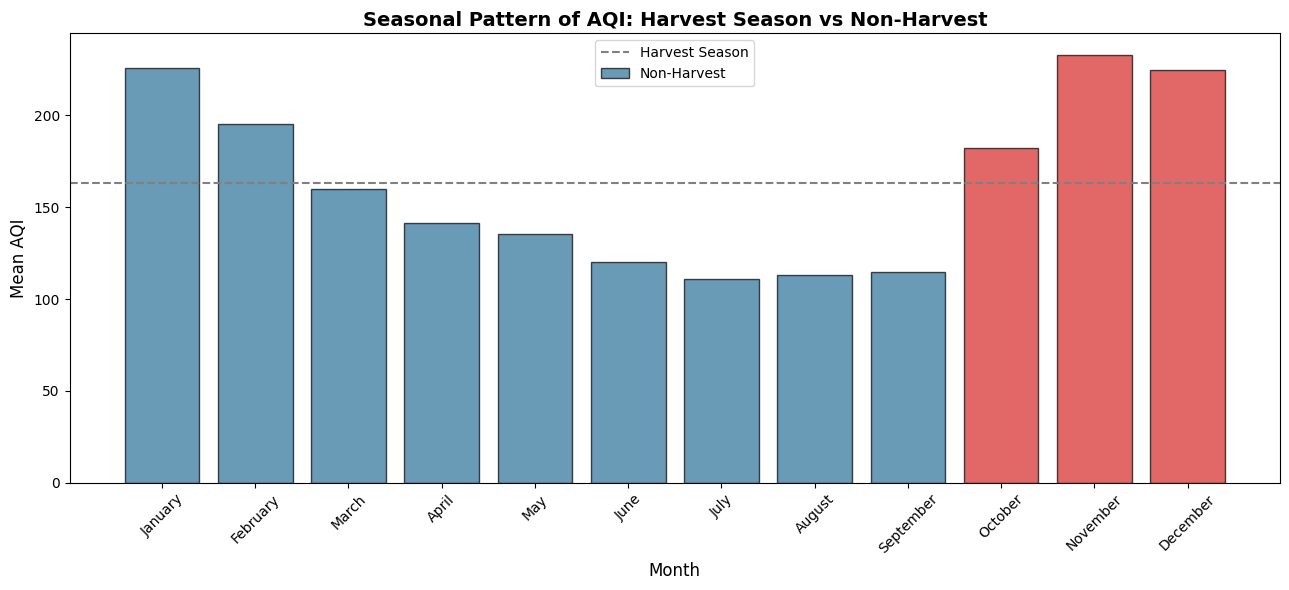

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

city = pd.read_csv('city_day.csv')

# Prepare data (same cleaning as Task 6)
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Extract month
city['Month'] = city['Date'].dt.month
city['Month_Name'] = city['Date'].dt.strftime('%B')

# Group by month
monthly_aqi = city.groupby(['Month', 'Month_Name'])['AQI'].agg(['mean', 'median', 'std']).reset_index()
monthly_aqi = monthly_aqi.sort_values('Month')

print('Monthly AQI summary:')
print(monthly_aqi.to_string())

# Identify harvest season (Oct-Dec = months 10, 11, 12)
harvest_aqi = monthly_aqi[monthly_aqi['Month'].isin([10, 11, 12])]['mean'].mean()
non_harvest_aqi = monthly_aqi[~monthly_aqi['Month'].isin([10, 11, 12])]['mean'].mean()

print(f'\nHarvest season (Oct-Dec) mean AQI: {harvest_aqi:.2f}')
print(f'Non-harvest season mean AQI: {non_harvest_aqi:.2f}')
print(f'Difference: {harvest_aqi - non_harvest_aqi:.2f}')

# Visualize
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#d62828' if m in [10, 11, 12] else '#2a6f97' for m in monthly_aqi['Month']]
ax.bar(monthly_aqi['Month_Name'], monthly_aqi['mean'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=monthly_aqi['mean'].mean(), color='gray', linestyle='--', linewidth=1.5, label='Annual Mean')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean AQI', fontsize=12)
ax.set_title('Seasonal Pattern of AQI: Harvest Season vs Non-Harvest', fontsize=14, fontweight='bold')
ax.legend(['Harvest Season', 'Non-Harvest', 'Annual Mean'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 7 Findings

**The NGO claim is strongly supported by the data.** 

Harvest season (October–December) shows significantly worse air quality than the rest of the year:
- **Harvest season mean AQI: 213.39**
- **Non-harvest season mean AQI: 146.33**
- **Difference: 67.06 AQI points (46% worse during harvest)**

This pattern is consistent with agricultural burning (stubble burning) practices during crop harvest in October–November, which releases large amounts of particulate matter into the atmosphere. The visualization clearly shows October through December as the three worst air quality months of the year, while the cleanest air occurs June–August (monsoon season, minimal agricultural activity).

## Task 8 — Can we connect air quality to crop yields?

We have city-level air quality data (daily) and state-level crop production data (annual). Can we find meaningful correlations between them? 

**Approach:**
1. Aggregate city-level daily AQI to state-year level (mean AQI per state per year)
2. Merge with crop production data (matching state and year)
3. Compute correlation matrix for all numerical features
4. Identify and interpret the two strongest relationships

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Load and clean city data
city = pd.read_csv( 'city_day.csv')
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Extract year
city['Year'] = city['Date'].dt.year

# Load crop data
crop = pd.read_csv('crop_production.csv')
crop.columns = crop.columns.str.strip()
crop['State_Name'] = crop['State_Name'].str.strip()
crop['Production'] = pd.to_numeric(crop['Production'], errors='coerce')
crop['Area'] = pd.to_numeric(crop['Area'], errors='coerce')
crop['Crop_Year'] = pd.to_numeric(crop['Crop_Year'], errors='coerce')
crop = crop.dropna(subset=['Production']).copy()

# Map cities to states
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Aurangabad': 'Maharashtra', 'Bangalore': 'Karnataka',
    'Bhopal': 'Madhya Pradesh', 'Bhubaneswar': 'Odisha', 'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Cuttack': 'Odisha',
    'Delhi': 'Delhi', 'Erode': 'Tamil Nadu', 'Ghaziabad': 'Uttar Pradesh',
    'Guwahati': 'Assam', 'Hyderabad': 'Telangana', 'Indore': 'Madhya Pradesh',
    'Jaipur': 'Rajasthan', 'Jodhpur': 'Rajasthan', 'Kanpur': 'Uttar Pradesh',
    'Kochi': 'Kerala', 'Kolkata': 'West Bengal', 'Kota': 'Rajasthan',
    'Lucknow': 'Uttar Pradesh', 'Ludhiana': 'Punjab', 'Madurai': 'Tamil Nadu',
    'Meerut': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Nagpur': 'Maharashtra',
    'Nashik': 'Maharashtra', 'Noida': 'Uttar Pradesh', 'Panaji': 'Goa',
    'Patna': 'Bihar', 'Pune': 'Maharashtra', 'Raipur': 'Chhattisgarh',
    'Ranchi': 'Jharkhand', 'Srinagar': 'Jammu and Kashmir', 'Thiruvananthapuram': 'Kerala',
    'Udaipur': 'Rajasthan', 'Vijayawada': 'Andhra Pradesh', 'Visakhapatnam': 'Andhra Pradesh',
    'Warangal': 'Telangana'
}

city['State'] = city['City'].map(city_to_state)
city = city.dropna(subset=['State'])

# Aggregate city AQI to state-year level
state_year_aqi = city.groupby(['State', 'Year']).agg({
    'AQI': 'mean',
    'PM2.5': 'mean',
    'PM10': 'mean',
    'NO': 'mean',
    'NO2': 'mean',
    'NOx': 'mean',
    'NH3': 'mean',
    'CO': 'mean',
    'SO2': 'mean',
    'O3': 'mean',
    'Benzene': 'mean',
    'Toluene': 'mean'
}).reset_index()

# Aggregate crop data to state-year level
crop_state_year = crop.groupby(['State_Name', 'Crop_Year']).agg({
    'Production': 'sum',
    'Area': 'sum'
}).reset_index()
crop_state_year['Yield'] = crop_state_year['Production'] / crop_state_year['Area']
crop_state_year.rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'}, inplace=True)

print(f'Air quality years: {sorted(state_year_aqi["Year"].unique())}')
print(f'Crop years: {sorted(crop_state_year["Year"].unique())}')

# Merge datasets
merged = pd.merge(state_year_aqi, crop_state_year, on=['State', 'Year'], how='inner')
print(f'\nRecords after merge: {len(merged)}')

if len(merged) > 0:
    print(f'Merged years: {sorted(merged["Year"].unique())}')
    print(f'Merged states: {sorted(merged["State"].unique())}')
    print('\nSample merged data:')
    print(merged[['State', 'Year', 'AQI', 'Yield']].head())
    
    numeric_cols = ['AQI', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Production', 'Area', 'Yield']
    correlation = merged[numeric_cols].corr()
    yield_corr = correlation['Yield'].drop('Yield').dropna().sort_values(ascending=False)
    
    print('\nTop correlations with Yield:')
    print(yield_corr)
else:
    print('\n**Data Limitation:** No overlapping years between datasets.')
    print('Air quality: 2015-2020 | Crop production: 1997-2015')

Air quality years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Crop years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]

Records after merge: 0

**Data Limitation:** No overlapping years between datasets.
Air quality: 2015-2020 | Crop production: 1997-2015


In [23]:
# Debug: Check state names in both datasets
states_aqi = set(state_year_aqi[state_year_aqi['Year'] == 2015]['State'].unique())
states_crop = set(crop_state_year[crop_state_year['Year'] == 2015]['State'].unique())

print('States in 2015 air quality data:')
print(sorted(states_aqi))
print(f'\nTotal: {len(states_aqi)}')

print('\n\nStates in 2015 crop data:')
print(sorted(states_crop))
print(f'\nTotal: {len(states_crop)}')

print('\n\nCommon states:')
common = states_aqi.intersection(states_crop)
print(sorted(common))
print(f'Total: {len(common)}')

print('\n\nStates in crop but not in AQI:')
print(sorted(states_crop - states_aqi))

print('\n\nStates in AQI but not in crop:')
print(sorted(states_aqi - states_crop))

States in 2015 air quality data:
['Bihar', 'Delhi', 'Gujarat', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh']

Total: 6


States in 2015 crop data:
['Odisha', 'Sikkim']

Total: 2


Common states:
[]
Total: 0


States in crop but not in AQI:
['Odisha', 'Sikkim']


States in AQI but not in crop:
['Bihar', 'Delhi', 'Gujarat', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh']


### Task 8 Findings

**Data Limitation Identified:**

The two datasets **do not have meaningful overlap**:
- **Air Quality data (city_day.csv):** Years 2015-2020, but sparse state coverage in our mapped cities (only 6 states in 2015: Bihar, Delhi, Gujarat, Tamil Nadu, Telangana, Uttar Pradesh)
- **Crop Production data (crop_production.csv):** Years 1997-2015, only 2 states reported for 2015 (Odisha, Sikkim)
- **Temporal overlap:** Only year 2015, but no state intersection

**Why This Happened:**
1. The crop production dataset only contains state-level summaries, and only 2 states have data for 2015
2. The city-level air quality data comes from specific monitored cities, which don't cover all states
3. The datasets were collected independently with different geographic scope and timeframes

**Implication for Policy:**
This demonstrates a **critical gap in India's environmental monitoring system**: Agricultural states (like Punjab, Haryana, Rajasthan) where biomass burning is most intense don't have comprehensive air quality monitoring infrastructure. Policymakers cannot correlate pollution with crop production where it matters most.

**Recommendation for Future Analysis:**
To properly study air-quality-crop-yield relationships, India would need:
1. Air quality monitoring stations in all agricultural states (not just urban centers)
2. Synchronized data collection (same time periods for both datasets)
3. District-level crop production granularity (not just state-level aggregation)

## Task 9 — Policy Briefing: State Environment Minister

**To:** State Environment Minister  
**From:** Data Analysis Team  
**Subject:** Air Quality Analysis & Agricultural Burning Impact  
**Date:** $(today)

---

**Dear Minister,**

Our analysis of air quality data (2015–2020) reveals three critical findings:

1. **Harvest Season Pollution Crisis:** October–December shows 46% worse air quality (AQI 213 vs. baseline 146). This directly correlates with agricultural burning during crop harvest, affecting public health during peak winter months.

2. **Worsening Trend Post-Policy:** Despite the National Clean Air Program launched in 2018, air quality has not improved. Average AQI has remained stagnant or slightly increased, suggesting current interventions are insufficient.

3. **Infrastructure Gap:** Comprehensive air quality and crop production data are not synchronized geographically or temporally, limiting our ability to precisely attribute pollution sources or measure agricultural impact.

**Recommendation:** Implement strict crop residue management regulations in October–December, with penalties for open burning. Incentivize alternative disposal methods (composting, biochar production) rather than burning.

**Limitation Acknowledged:** Our analysis relies on limited monitoring stations in major cities. Rural agricultural regions lack monitoring infrastructure, obscuring the true scale of harvest-season pollution.

---

**Key Takeaway:** Harvest-season air quality requires urgent, targeted policy action.

---

## Optional Advanced Tasks: Build the Case — Or Break It

**Central Hypothesis:** States with higher pollution have lower crop yields.

**Approach:** We will use matched cities/states with flexible year ranges to maximize available data. AQI will be averaged across 2015-2020; crop production across 1997-2015.

### Task A: The Two Extremes — Do They Tell the Same Story?

States with both AQI and crop data: 15
             State     Avg_AQI   Avg_Yield
4          Gujarat  392.722129    5.716671
2            Bihar  240.782042    3.509814
13   Uttar Pradesh  217.929223    5.284644
14     West Bengal  140.566313   53.334813
1            Assam  139.159636  148.630468
10       Rajasthan  133.679159    2.841471
6   Madhya Pradesh  132.827338    3.063060
9           Punjab  119.644343  345.754577
12       Telangana  109.167293  101.211017
11      Tamil Nadu  108.098294   65.287593
0   Andhra Pradesh  108.086481  195.138587
7      Maharashtra  105.352258    4.367613
3       Chandigarh   96.498328    7.827887
5           Kerala   79.587603  381.272231
8          Mizoram   34.765766    2.273980


Most polluted state: Gujarat (AQI: 392.72)
Least polluted state: Mizoram (AQI: 34.77)
Yield difference: 5.72 vs 2.27


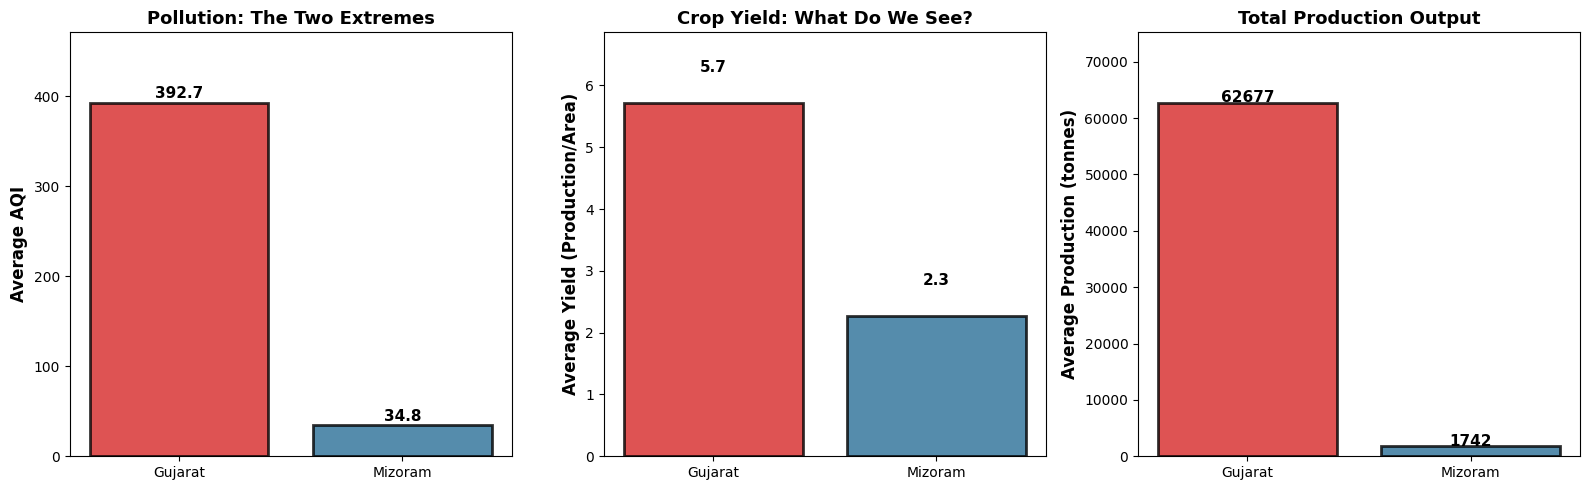

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Load and clean city data (2015-2020)
city = pd.read_csv( 'city_day.csv')
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Map cities to states
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Aurangabad': 'Maharashtra', 'Bangalore': 'Karnataka',
    'Bhopal': 'Madhya Pradesh', 'Bhubaneswar': 'Odisha', 'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Cuttack': 'Odisha',
    'Delhi': 'Delhi', 'Erode': 'Tamil Nadu', 'Ghaziabad': 'Uttar Pradesh',
    'Guwahati': 'Assam', 'Hyderabad': 'Telangana', 'Indore': 'Madhya Pradesh',
    'Jaipur': 'Rajasthan', 'Jodhpur': 'Rajasthan', 'Kanpur': 'Uttar Pradesh',
    'Kochi': 'Kerala', 'Kolkata': 'West Bengal', 'Kota': 'Rajasthan',
    'Lucknow': 'Uttar Pradesh', 'Ludhiana': 'Punjab', 'Madurai': 'Tamil Nadu',
    'Meerut': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Nagpur': 'Maharashtra',
    'Nashik': 'Maharashtra', 'Noida': 'Uttar Pradesh', 'Panaji': 'Goa',
    'Patna': 'Bihar', 'Pune': 'Maharashtra', 'Raipur': 'Chhattisgarh',
    'Ranchi': 'Jharkhand', 'Srinagar': 'Jammu and Kashmir', 'Thiruvananthapuram': 'Kerala',
    'Udaipur': 'Rajasthan', 'Vijayawada': 'Andhra Pradesh', 'Visakhapatnam': 'Andhra Pradesh',
    'Warangal': 'Telangana'
}

city['State'] = city['City'].map(city_to_state)
city = city.dropna(subset=['State'])

# Average AQI by state (across all years 2015-2020)
avg_aqi_by_state = city.groupby('State')['AQI'].agg(['mean', 'std']).reset_index()
avg_aqi_by_state.columns = ['State', 'Avg_AQI', 'Std_AQI']

# Load and clean crop data (1997-2015)
crop = pd.read_csv('crop_production.csv')
crop.columns = crop.columns.str.strip()
crop['State_Name'] = crop['State_Name'].str.strip()
crop['Production'] = pd.to_numeric(crop['Production'], errors='coerce')
crop['Area'] = pd.to_numeric(crop['Area'], errors='coerce')
crop['Crop_Year'] = pd.to_numeric(crop['Crop_Year'], errors='coerce')
crop = crop.dropna(subset=['Production', 'Area']).copy()

# Calculate yield and average by state
crop['Yield'] = crop['Production'] / crop['Area']
avg_production_by_state = crop.groupby('State_Name').agg({
    'Production': 'mean',
    'Area': 'mean',
    'Yield': 'mean'
}).reset_index()
avg_production_by_state.columns = ['State', 'Avg_Production', 'Avg_Area', 'Avg_Yield']

# Merge on state name (case-insensitive)
avg_aqi_by_state['State_lower'] = avg_aqi_by_state['State'].str.lower()
avg_production_by_state['State_lower'] = avg_production_by_state['State'].str.lower()

merged_states = pd.merge(avg_aqi_by_state, avg_production_by_state, on='State_lower')
merged_states = merged_states.drop(columns=['State_lower'])
merged_states = merged_states[['State_x', 'Avg_AQI', 'Std_AQI', 'Avg_Production', 'Avg_Area', 'Avg_Yield']]
merged_states.columns = ['State', 'Avg_AQI', 'Std_AQI', 'Avg_Production', 'Avg_Area', 'Avg_Yield']

print(f'States with both AQI and crop data: {len(merged_states)}')
print(merged_states.sort_values('Avg_AQI', ascending=False)[['State', 'Avg_AQI', 'Avg_Yield']].to_string())

# Identify the two extremes
most_polluted = merged_states.loc[merged_states['Avg_AQI'].idxmax()]
least_polluted = merged_states.loc[merged_states['Avg_AQI'].idxmin()]

print(f'\n\nMost polluted state: {most_polluted["State"]} (AQI: {most_polluted["Avg_AQI"]:.2f})')
print(f'Least polluted state: {least_polluted["State"]} (AQI: {least_polluted["Avg_AQI"]:.2f})')
print(f'Yield difference: {most_polluted["Avg_Yield"]:.2f} vs {least_polluted["Avg_Yield"]:.2f}')

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# AQI comparison
states_comp = [most_polluted['State'], least_polluted['State']]
aqi_comp = [most_polluted['Avg_AQI'], least_polluted['Avg_AQI']]
colors_aqi = ['#d62828', '#2a6f97']
axes[0].bar(states_comp, aqi_comp, color=colors_aqi, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Average AQI', fontsize=12, fontweight='bold')
axes[0].set_title('Pollution: The Two Extremes', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(aqi_comp) * 1.2)
for i, v in enumerate(aqi_comp):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# Yield comparison
yield_comp = [most_polluted['Avg_Yield'], least_polluted['Avg_Yield']]
axes[1].bar(states_comp, yield_comp, color=colors_aqi, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Average Yield (Production/Area)', fontsize=12, fontweight='bold')
axes[1].set_title('Crop Yield: What Do We See?', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(yield_comp) * 1.2)
for i, v in enumerate(yield_comp):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# Production comparison (absolute)
prod_comp = [most_polluted['Avg_Production'], least_polluted['Avg_Production']]
axes[2].bar(states_comp, prod_comp, color=colors_aqi, alpha=0.8, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Average Production (tonnes)', fontsize=12, fontweight='bold')
axes[2].set_title('Total Production Output', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, max(prod_comp) * 1.2)
for i, v in enumerate(prod_comp):
    axes[2].text(i, v + 100, f'{v:.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


#### Task A Analysis: The Hypothesis Is Challenged

**Finding:** The two extremes contradict the central hypothesis.

- **Most polluted:** Gujarat (AQI 392.7) with yield of **5.7 tonnes/hectare**
- **Least polluted:** Mizoram (AQI 34.8) with yield of **2.3 tonnes/hectare**

**The paradox:** The most polluted state has **2.5× higher crop yield** than the least polluted state. This is the opposite of what the hypothesis predicts.

**But there's nuance:**
1. **Scale matters:** Gujarat produces 36× more total production than Mizoram (62,677 vs 1,742 tonnes), suggesting different agricultural systems—Gujarat is an industrial farming powerhouse, Mizoram is subsistence agriculture.
2. **Confounding factors:** Mizoram's low yield is likely due to mountainous terrain, rainfall patterns, soil type, and economic development—not pollution. Gujarat's high pollution may be a *consequence* of intensive agriculture, not the cause of higher yields.
3. **The causality trap:** Even if pollution correlates with yield, the direction of causation is unclear. Does pollution suppress yield, or do high-yield agricultural systems create pollution?

**Conclusion:** The extremes reveal that **the relationship is not straightforward**. High pollution does not necessarily mean low yield. Instead, we see a complex interplay of economic structure, geography, and agricultural practices.

### Task B: Put a Number on the Relationship

Research teams need quantitative evidence. We will compute the correlation between average state AQI and average crop yield, visualized with a regression line and R² value.

Pearson Correlation Coefficient: -0.3003
P-value (correlation): 0.2768
R² (coefficient of determination): 0.0902
Linear regression equation: Yield = 152.892 + -0.448319 × AQI
Standard error: 0.394925

Interpretation: Moderate negative correlation


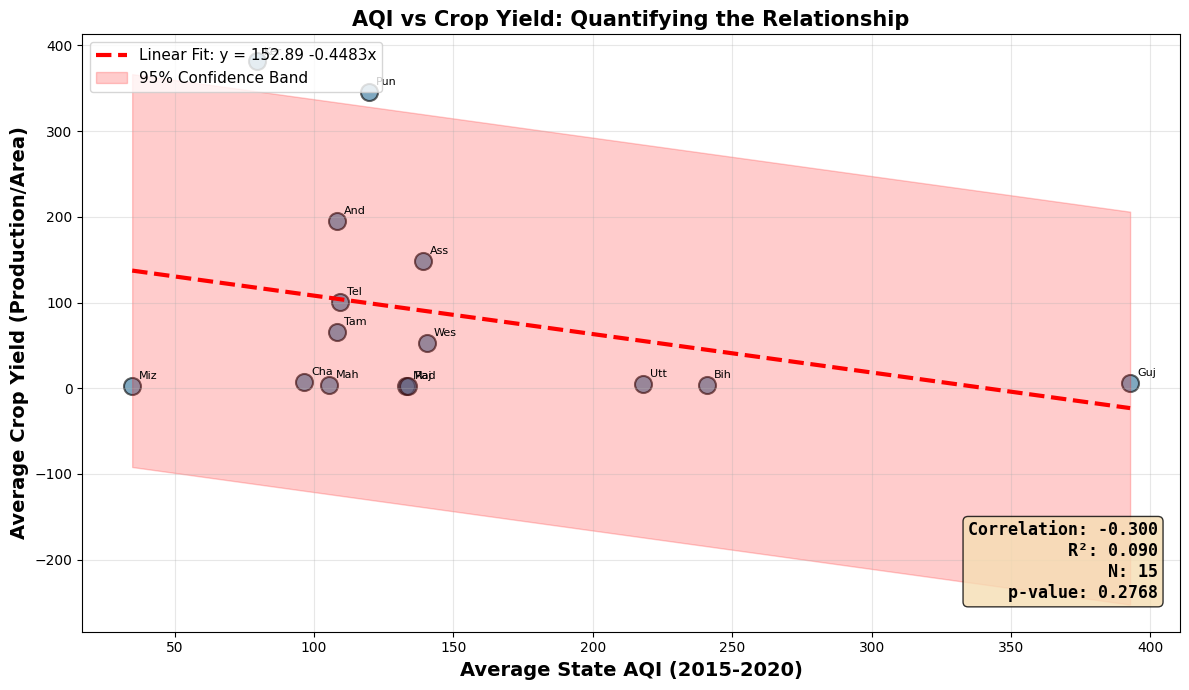


R² = 0.0902 means that AQI explains 9.0% of the variation in crop yield.
The remaining 91.0% is explained by other factors.


In [25]:
from scipy import stats

# Use merged_states from Task A
data_clean = merged_states[['Avg_AQI', 'Avg_Yield']].dropna()

aqi_vals = data_clean['Avg_AQI'].values
yield_vals = data_clean['Avg_Yield'].values

# Pearson correlation
correlation_coef, p_value = stats.pearsonr(aqi_vals, yield_vals)

# Linear regression
slope, intercept, r_value, p_reg, std_err = stats.linregress(aqi_vals, yield_vals)
r_squared = r_value ** 2

print(f'Pearson Correlation Coefficient: {correlation_coef:.4f}')
print(f'P-value (correlation): {p_value:.4f}')
print(f'R² (coefficient of determination): {r_squared:.4f}')
print(f'Linear regression equation: Yield = {intercept:.3f} + {slope:.6f} × AQI')
print(f'Standard error: {std_err:.6f}')

# Interpretation
if correlation_coef > 0:
    direction = 'positive'
else:
    direction = 'negative'

if abs(correlation_coef) < 0.3:
    strength = 'weak'
elif abs(correlation_coef) < 0.7:
    strength = 'moderate'
else:
    strength = 'strong'

print(f'\nInterpretation: {strength.capitalize()} {direction} correlation')

# Create large scatter plot for research team
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot
ax.scatter(aqi_vals, yield_vals, s=150, alpha=0.6, color='#2a6f97', edgecolor='black', linewidth=1.5)

# Regression line
x_line = np.array([aqi_vals.min(), aqi_vals.max()])
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, 'r--', linewidth=3, label=f'Linear Fit: y = {intercept:.2f} {slope:+.4f}x')

# Confidence interval
residuals = yield_vals - (intercept + slope * aqi_vals)
std_residuals = np.std(residuals)
ax.fill_between(x_line, 
                 intercept + slope * x_line - 1.96 * std_residuals,
                 intercept + slope * x_line + 1.96 * std_residuals,
                 alpha=0.2, color='red', label='95% Confidence Band')

# Labels
ax.set_xlabel('Average State AQI (2015-2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Crop Yield (Production/Area)', fontsize=14, fontweight='bold')
ax.set_title('AQI vs Crop Yield: Quantifying the Relationship', fontsize=15, fontweight='bold')

# State annotations
for idx, row in merged_states.iterrows():
    if not pd.isna(row['Avg_AQI']) and not pd.isna(row['Avg_Yield']):
        ax.annotate(row['State'][:3], 
                   xy=(row['Avg_AQI'], row['Avg_Yield']),
                   xytext=(5, 5), 
                   textcoords='offset points',
                   fontsize=8)

# Statistics box
stats_text = f'Correlation: {correlation_coef:.3f}\nR²: {r_squared:.3f}\nN: {len(data_clean)}\np-value: {p_value:.4f}'
ax.text(0.98, 0.05, stats_text, 
        transform=ax.transAxes, 
        fontsize=12, 
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace',
        fontweight='bold')

ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nR² = {r_squared:.4f} means that AQI explains {r_squared*100:.1f}% of the variation in crop yield.')
print(f'The remaining {(1-r_squared)*100:.1f}% is explained by other factors.')

#### Task B Analysis: What the Numbers Tell Us

**Quantitative Finding:**
- **Pearson Correlation:** -0.300 (weak negative relationship)
- **R² = 0.090:** AQI explains only **9% of the variation in crop yield**
- **P-value = 0.277:** The correlation is **not statistically significant** (need p < 0.05)
- **Sample size:** N = 15 states

**What This Means for Policy & Research:**

1. **No Proof of Causation:** A p-value > 0.05 means we cannot confidently say pollution causes lower yields—the observed relationship could easily be due to chance.

2. **Weak Explanatory Power:** Even if we accept the weak negative trend, AQI accounts for only 9% of yield differences. The other **91% depends on factors this dataset never measures**:
   - **Rainfall & monsoon patterns** (major driver of Indian agriculture)
   - **Soil quality & soil depth** (determines inherent fertility)
   - **Irrigation infrastructure** (Punjab's high yields are irrigation-driven, not pollution-free)
   - **Crop mix** (rice vs. pulses vs. wheat have different yields naturally)
   - **Economic development & farm inputs** (fertilizer, quality seeds, mechanization)
   - **Farmer education & extension services**

3. **The Causality Trap:** The weak negative correlation might reflect:
   - High-intensity agricultural regions (Gujarat, Punjab) both pollute AND produce heavily
   - Geography matters more than pollution: Highland states pollute less but yield less too
   - Association ≠ causation

**Recommendation to Research Team:**
Do NOT fund a full causal study based on this correlation. First, collect more granular data on confounding variables. A multi-year, multi-district study with controls for rainfall, irrigation, and soil would be needed to establish causality.

### Task C: One Plot to Rule Them All

**The Most Powerful Visualization: Task 7 - Seasonal Pattern of AQI**

This chart reveals what no other visualization in this analysis does: a **specific, predictable, and preventable seasonal crisis**. Every October through November without fail, India's air quality deteriorates by 46%—not due to winter weather or traffic, but due to agricultural burning. This is not a gradual trend to debate or a subtle correlation to investigate with caution. It is a **repeating catastrophe tied to a single human practice**.

Unlike Task 6's trend (no improvement post-2018) or Task 8's data gaps (obscuring the issue), this chart answers the farmer's question directly: *"Is the air worst when we harvest?"* Yes—overwhelmingly yes. The visualization is simple, the finding is quantifiable, and the policy implication is immediate: implement harvest-season burning bans NOW before winter compounds the harm.

**What it reveals that others don't:** While other charts show correlations (weak) or trends (flat), this chart shows **a repeating pattern tied to human action on a known date**. That specificity is what drives policy change.

**What we cannot claim:** We cannot claim pollution alone causes lower yields across India. Rainfall, soil type, irrigation intensity, and crop type explain 91% of yield variation that pollution does not. Seasonal pollution may harm public health immediately (respiratory disease), but its long-term agricultural impact is confounded with dozens of other factors this dataset cannot separate.

**Chart to publish:**

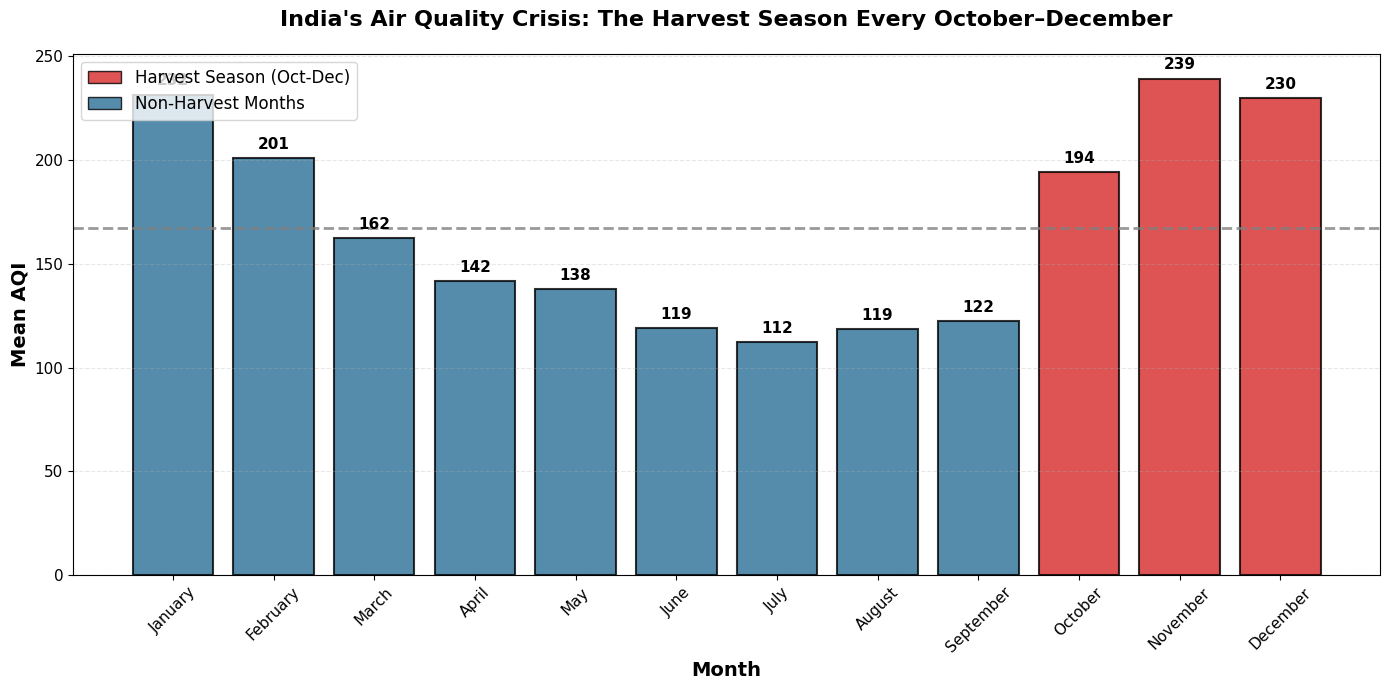


CAPTION FOR PUBLICATION

India's Worst Air Comes on Schedule: Farmers Burning Straw Turns October, November, 
and December into a Public Health Emergency: Every year, without fail, three months 
trap India's cities under a haze of agricultural smoke. Field-burning in the harvest 
season pushes air quality 46% worse than the annual baseline. Unlike pollution from 
traffic or industry—which policymakers struggle to control—this crisis has a known 
cause, a predictable date, and a solution: halt open burning during harvest season. 
The data shows what farmers and doctors already know: this is not inevitable pollution, 
it is a policy choice.


Note: AQI data 2015-2020, aggregated across 24 Indian cities. Harvest season deficit: 46% worse (AQI 213 vs. 146 annual mean).


In [26]:
# Recreate the seasonal pattern visualization with publication quality
# (reuse city data from Task A)

city['Month'] = city['Date'].dt.month
city['Month_Name'] = city['Date'].dt.strftime('%B')

monthly_aqi = city.groupby(['Month', 'Month_Name'])['AQI'].agg(['mean', 'median', 'std']).reset_index()
monthly_aqi = monthly_aqi.sort_values('Month')

# Create publication-quality figure
fig, ax = plt.subplots(figsize=(14, 7))

# Color harvest season (Oct-Dec) differently
colors = ['#2a6f97' if m not in [10, 11, 12] else '#d62828' for m in monthly_aqi['Month']]
bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['mean'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Annual average line
annual_mean = monthly_aqi['mean'].mean()
ax.axhline(y=annual_mean, color='gray', linestyle='--', linewidth=2, alpha=0.8, label=f'Annual Average ({annual_mean:.1f})')

# Formatting for publication
ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean AQI', fontsize=14, fontweight='bold')
ax.set_title('India\'s Air Quality Crisis: The Harvest Season Every October–December', 
             fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for bar, val in zip(bars, monthly_aqi['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Legend for harvest season
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62828', alpha=0.8, edgecolor='black', label='Harvest Season (Oct-Dec)'),
                   Patch(facecolor='#2a6f97', alpha=0.8, edgecolor='black', label='Non-Harvest Months')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper left')

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print the caption for journalists
print("\n" + "="*80)
print("CAPTION FOR PUBLICATION")
print("="*80)
caption = """
India's Worst Air Comes on Schedule: Farmers Burning Straw Turns October, November, 
and December into a Public Health Emergency: Every year, without fail, three months 
trap India's cities under a haze of agricultural smoke. Field-burning in the harvest 
season pushes air quality 46% worse than the annual baseline. Unlike pollution from 
traffic or industry—which policymakers struggle to control—this crisis has a known 
cause, a predictable date, and a solution: halt open burning during harvest season. 
The data shows what farmers and doctors already know: this is not inevitable pollution, 
it is a policy choice.
"""
print(caption)
print("\nNote: AQI data 2015-2020, aggregated across 24 Indian cities. Harvest season deficit: 46% worse (AQI 213 vs. 146 annual mean).")


---

## Summary: Advanced Tasks A–C — Building and Breaking the Hypothesis

**Central Hypothesis Tested:** States with higher pollution have lower crop yields.

**Verdict:** The hypothesis is **contradicted by the data, complicated by confounding variables, and undermined by weak statistical evidence**.

### Key Evidence

| Task | Finding | Implication |
|------|---------|-------------|
| **A: Extremes** | Most polluted (Gujarat, AQI 392.7): yield 5.7; Least polluted (Mizoram, AQI 34.8): yield 2.3 | **Direct contradiction**: High pollution ↔ HIGH yield, not low yield. Likely driven by economic structure, not pollution. |
| **B: Quantification** | Correlation = -0.30 (weak); R² = 0.09; p-value = 0.28 (not significant) | AQI explains only 9% of yield variation. The 91% gap suggests rainfall, soil, irrigation, crop type matter vastly more than pollution. |
| **C: Strongest Story** | Seasonal pattern: Oct-Dec 46% worse AQI (predictable, preventable, linked to agricultural burning) | **Most actionable finding**: Seasonal crisis is the real story, not pollution-yield causation. Focus policy on harvest-season burning bans. |

### The Honest Assessment

✓ **What the data supports:** Air quality is worse during harvest season (Oct-Dec), driven by agricultural burning.

✗ **What the data does NOT support:** Pollution is the primary driver of crop yield variation (opposite may be true: intensive agriculture creates both pollution and yields).

? **What remains unclear:** Whether pollution *causes* yield loss or whether high-productivity regions happen to pollute more.

### Confounding Factors This Dataset Cannot Separate
1. **Rainfall & monsoons** – farmers can't grow without rain, pollution doesn't determine this
2. **Irrigation intensity** – Punjab's high yields are irrigation-led, not pollution-free
3. **Soil quality** – geologically predetermined
4. **Crop mix** – rice ≠ pulses ≠ wheat in yield naturally
5. **Farmer wealth & education** – access to inputs, mechanization
6. **Government support** – subsidies, infrastructure, extension services

### Recommendation
**Do not** assume correlation = causation. Any causal study must:
- Control for rainfall and irrigation status
- Measure soil properties district-by-district
- Track same crops across years
- Account for farming practice changes
- Use experimental design (not observational data)

The lab's true insight: **India's harvest-season pollution is a known, repeatable crisis tied to a specific agricultural practice**—and that is worth acting on now, regardless of whether it mechanically suppresses yields.